In [1]:
import os
import torch
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from detectgpt_lightweight import LightweightDetectGPT

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
DATAPATH = '../../data/'

In [3]:
!pwd

/home/jupyter/project/ai_detector_diploma/src/detector


In [4]:
df = pd.read_csv(os.path.join(DATAPATH, 'final_dataset.csv'))
df

,article_id,chunk_id,text,label,ai_spans_json,ai_span_start_char,ai_span_end_char,ai_span_start_word,ai_span_end_word,ai_fraction,has_mixed_content,strategy,source_model,judge_semantic_score,judge_complexity_score,judge_avg,word_count,char_count,chunk_index,total_chunks,original_chunk_id,created_at
0,modernizatsiya-strany-i-nekotorye-problemy-gum...,modernizatsiya-strany-i-nekotorye-problemy-gum...,ОБЩАЯ ПЕДАГОГИКА. ИСТОРИЯ ПЕДАГОГИКИ И ОБРАЗОВ...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,865,7103,0,2,modernizatsiya-strany-i-nekotorye-problemy-gum...,2026-03-31T10:50:19.251314
1,modernizatsiya-strany-i-nekotorye-problemy-gum...,modernizatsiya-strany-i-nekotorye-problemy-gum...,"По сути, сфера смыслов оказывается в фокусе на...",0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,813,6993,1,2,modernizatsiya-strany-i-nekotorye-problemy-gum...,2026-03-31T10:50:19.251314
2,prak-tiki-tsivilizatsionnogo-realizma,prak-tiki-tsivilizatsionnogo-realizma_chunk0_h...,ПРАКТИКИ ЦИВИЛИЗАЦИОННОГО РЕАЛИЗМА Аннотация В...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,698,5928,0,5,prak-tiki-tsivilizatsionnogo-realizma_chunk0_h...,2026-03-31T10:50:19.562318
3,prak-tiki-tsivilizatsionnogo-realizma,prak-tiki-tsivilizatsionnogo-realizma_chunk1_h...,"""Евразийский смысл — самоуглубляющаяся структу...",0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,699,6031,1,5,prak-tiki-tsivilizatsionnogo-realizma_chunk1_h...,2026-03-31T10:50:19.562318
4,prak-tiki-tsivilizatsionnogo-realizma,prak-tiki-tsivilizatsionnogo-realizma_chunk2_h...,В практическом плане представители российского...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,953,8165,2,5,prak-tiki-tsivilizatsionnogo-realizma_chunk2_h...,2026-03-31T10:50:19.562318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3455,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,А. В. Кольцов. Категории «божественного» и «св...,1,"[[0, 5430]]",0.0,5430.0,0.0,674.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,4.0,4.0,674,5430,0,4,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,2026-03-31T13:48:15.812460
3456,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,Тем не менее было бы ошибкой полностью отрицат...,1,"[[0, 6724]]",0.0,6724.0,0.0,804.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,4.0,4.0,804,6724,1,4,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,2026-03-31T13:49:17.465399
3457,arheologicheskie-raboty-tamanskoy-ekspeditsii-...,arheologicheskie-raboty-tamanskoy-ekspeditsii-...,В 1930 году сотрудники Таманской экспедиции Го...,1,"[[0, 5806]]",0.0,5806.0,0.0,785.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,5.0,5.0,785,5806,3,7,arheologicheskie-raboty-tamanskoy-ekspeditsii-...,2026-03-31T13:50:05.384080
3458,rabota-politologa-po-strategicheskomu-planirov...,rabota-politologa-po-strategicheskomu-planirov...,Некоторые краткие выводы из исследования.\n\n1...,1,"[[0, 5409]]",0.0,5409.0,0.0,705.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,3.0,3.5,705,5409,8,10,rabota-politologa-po-strategicheskomu-planirov...,2026-03-31T13:50:53.127274


In [5]:
df.iloc[1000]['text']

'Во втором классе ученики осваивают навыки коллективной жизни, учатся взаимодействовать с другими людьми, постигают правила общения и этики. Они учатся осознавать свои социальные роли, такие как «я — друг», «я — ученик (ученица)», и ориентироваться в различных ситуациях повседневной жизни, например, «я — пешеход», «я — покупатель». Дети знакомятся с разными профессиями, такими как учитель, врач, экономист, и учатся действовать в соответствии с требованиями общества.\n\nВ третьем классе ученики осознают себя частью общества и понимают необходимость соблюдения его норм. Они изучают проблемы человека и общества, узнают о взаимосвязи человека и природы. Ученики учатся ценить себя, других людей, природу и свою страну, осознают важность ответственности за свою жизнь и жизнь других людей. Они развивают в себе качества достойного гражданина многонациональной страны, учатся ориентироваться в элементарных политических вопросах и формируют гражданскую позицию.\n\nВ четвёртом классе ученики получа

In [6]:
df.iloc[1000][['ai_span_start_word', 'ai_span_end_word', 'ai_fraction']]

ai_span_start_word      0.0
ai_span_end_word      272.0
ai_fraction             1.0
Name: 1000, dtype: object

In [7]:
df['strategy'].unique()

array(['original', 'paraphrase_deep', 'paraphrase_human_voice',
       'partial_continuation', 'partial_middle_insert',
       'back_translation'], dtype=object)

In [8]:
df['source_model'].unique()

array(['Human', 'Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-lite'],
      dtype=object)

In [9]:
human = df[(df['label'] == 0) & (df['ai_fraction'] == 0.0)]
ai = df[(df['label'] == 1) & (df['ai_fraction'] == 1.0)]

print(f"Human texts: {len(human)}, AI texts: {len(ai)}")

Human texts: 825, AI texts: 1489


In [10]:
sample_size = 500
human_sample = human.sample(min(sample_size, len(human)), random_state=42)
ai_sample = ai.sample(min(sample_size, len(ai)), random_state=42)

In [11]:
texts_human = human_sample['text'].tolist()
texts_ai = ai_sample['text'].tolist()
all_texts = texts_human + texts_ai
true_labels = [0]*len(texts_human) + [1]*len(texts_ai)

print(f"Total samples: {len(all_texts)}")

Total samples: 1000


In [12]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
Device name: Tesla V100-PCIE-32GB


In [14]:
import logging

class SuppressSpanWarning(logging.Filter):
    def filter(self, record):
        return "Reducing number of spans" not in record.getMessage()

logger = logging.getLogger("detectgpt_lightweight")
logger.addFilter(SuppressSpanWarning())


detector = LightweightDetectGPT(
    target_model_name='gpt2',
    perturbation_model_name='t5-base',
    num_perturbations=10,
    batch_size=64,
    mask_rate=0.15,
    span_length=4,
    max_length=512,
    log_prob_type='mean',
    device='cuda'
)

INFO:detectgpt_lightweight:Loading target model: gpt2
INFO:detectgpt_lightweight:Loading perturbation model: t5-base
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
INFO:detectgpt_lightweight:Maximum sentinel tokens available: 100


In [ ]:
results = detector.detect_batch(all_texts)

curv = [r['curvature'] for r in results]
norm_curv = [r['normalized_curvature'] for r in results]
orig_lp = [r['original_log_prob'] for r in results]

INFO:detectgpt_lightweight:Batch detecting 1000 texts
Computing log probs: 100%|██████████| 172/172 [01:20<00:00,  2.14it/s]


In [19]:
df_eval = pd.DataFrame({
    'label': true_labels,
    'curvature': curv,
    'normalized_curvature': norm_curv,
    'log_prob': orig_lp
})

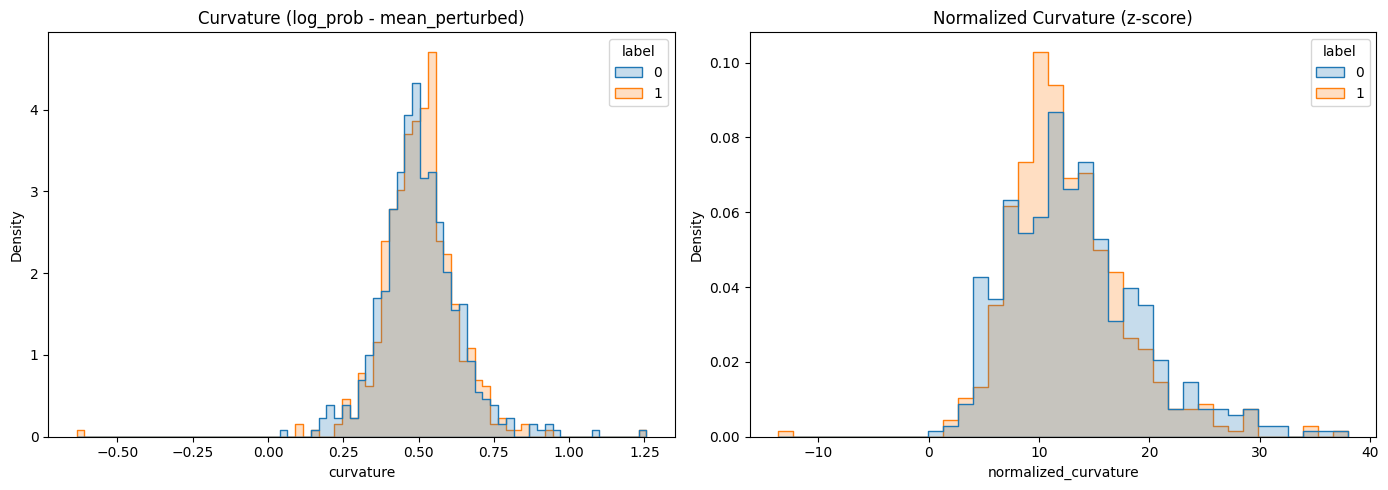

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(
    axes,
    ['curvature', 'normalized_curvature'],
    ['Curvature (log_prob - mean_perturbed)', 'Normalized Curvature (z-score)']
):
    sns.histplot(data=df_eval, x=metric, hue='label', element='step',
                 stat='density', common_norm=False, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

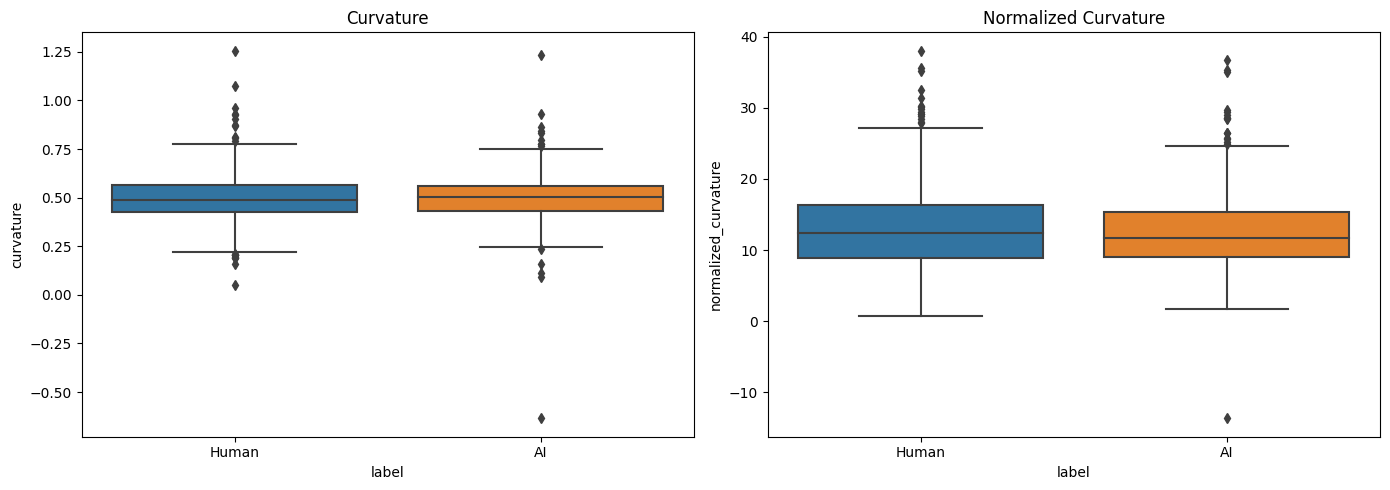

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(
    axes,
    ['curvature', 'normalized_curvature'],
    ['Curvature', 'Normalized Curvature']
):
    sns.boxplot(data=df_eval, x='label', y=metric, ax=ax)
    ax.set_xticklabels(['Human', 'AI'])
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [22]:
fpr, tpr, thresholds = roc_curve(true_labels, norm_curv)
auc_score = roc_auc_score(true_labels, norm_curv)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"AUC (normalized curvature): {auc_score:.4f}")
print(f"Optimal threshold (max Youden): {optimal_threshold:.4f}")

AUC (normalized curvature): 0.4723
Optimal threshold (max Youden): 6.5258


In [23]:
preds = (np.array(norm_curv) >= optimal_threshold).astype(int)
print("\nClassification Report:")
print(classification_report(true_labels, preds, target_names=['Human', 'AI']))


Classification Report:
              precision    recall  f1-score   support

       Human       0.62      0.12      0.20       500
          AI       0.51      0.93      0.66       500

    accuracy                           0.52      1000
   macro avg       0.57      0.52      0.43      1000
weighted avg       0.57      0.52      0.43      1000



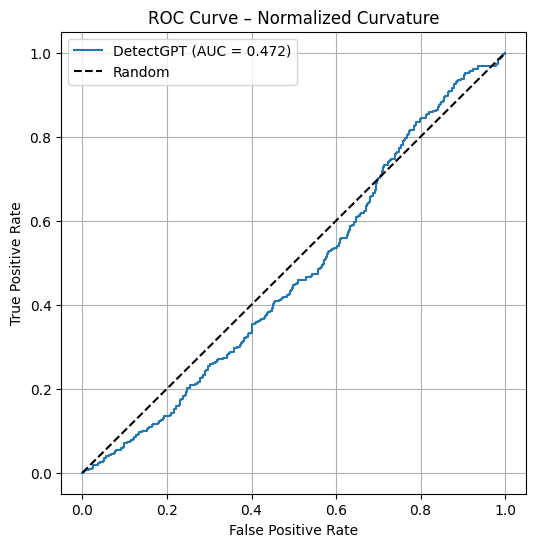

In [24]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'DetectGPT (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Normalized Curvature')
plt.legend()
plt.grid(True)
plt.show()